In [6]:
# Import required libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

In [8]:
# Load the raw text file
with open("news_data.json", "r", encoding="utf-8") as f:
    raw_text = f.read()

# Remove the prefix so that only valid JSON remains
raw_text = raw_text.replace("news api: ", "", 1)

# Convert cleaned text into a Python dictionary
data = json.loads(raw_text)

# Extract the articles and convert them into a DataFrame
df_news = pd.DataFrame(data["articles"])

# Show first rows
df_news.head()

,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': None, 'name': 'Noe.orf.at'}",ORF.at,Koch-Lehrlinge als Zukunftshoffnung für Gastro,Zahlreiche der landesweit 8.000 Gastrobetriebe...,https://noe.orf.at/stories/3343578/,https://ibs.orf.at/noe?image=https%3A%2F%2Foek...,2026-03-01T12:10:23Z,"Personalmangel, hohe Inflation, gestiegene Ene..."
1,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Verbraucherpreise: Energie günstiger: Inflatio...,Hier finden Sie Informationen zu dem Thema „Ve...,https://www.zeit.de/news/2026-02/27/energie-gu...,https://img.zeit.de/news/2026-02/27/energie-gu...,2026-02-27T13:18:26Z,Kaum noch Preisanstiege bei Lebensmitteln und ...
2,"{'id': None, 'name': 'STERN.de'}",STERN.de,Verbraucherpreise: Energie günstiger: Inflatio...,"Lebensmittel, Heizen, Restaurantbesuche: Das L...",https://www.stern.de/news/verbraucherpreise--e...,https://image.stern.de/37177240/t/jJ/v1/w1440/...,2026-02-27T13:18:26Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
3,"{'id': None, 'name': 'STERN.de'}",STERN.de,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Wiesbaden (lhe) - Hessens Arbeitnehmer haben i...,https://www.stern.de/gesellschaft/regional/hes...,https://image.stern.de/37177216/t/OL/v1/w1440/...,2026-02-27T13:08:04Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
4,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Hier finden Sie Informationen zu dem Thema „Lö...,https://www.zeit.de/news/2026-02/27/mehr-kaufk...,https://img.zeit.de/news/2026-02/27/mehr-kaufk...,2026-02-27T13:08:04Z,Hessens Arbeitnehmer haben im vergangenen Jahr...


In [10]:
# Define German media domains
german_domains = [
    "zeit.de",
    "stern.de",
    "faz.net",
    "tagesspiegel.de",
    "sueddeutsche.de",
    "focus.de",
    "morgenpost.de",
    "tagesschau.de"
]

# Keep only Germany-related articles
df_germany = df_news[
    df_news["url"].str.contains("|".join(german_domains), case=False, na=False) |
    df_news["title"].str.contains("Deutschland|deutsch|deutsche|Berlin|Brandenburg|Bremen|Sachsen|Hessen", case=False, na=False) |
    df_news["description"].str.contains("Deutschland|deutsch|deutsche|Berlin|Brandenburg|Bremen|Sachsen|Hessen", case=False, na=False) |
    df_news["content"].str.contains("Deutschland|deutsch|deutsche|Berlin|Brandenburg|Bremen|Sachsen|Hessen", case=False, na=False)
].copy()

# Show number of German articles
print("Number of German-related articles:", len(df_germany))

# Display selected columns
df_germany[["title", "url", "publishedAt"]].head(10)

Number of German-related articles: 31


,title,url,publishedAt
1,Verbraucherpreise: Energie günstiger: Inflatio...,https://www.zeit.de/news/2026-02/27/energie-gu...,2026-02-27T13:18:26Z
2,Verbraucherpreise: Energie günstiger: Inflatio...,https://www.stern.de/news/verbraucherpreise--e...,2026-02-27T13:18:26Z
3,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,https://www.stern.de/gesellschaft/regional/hes...,2026-02-27T13:08:04Z
4,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,https://www.zeit.de/news/2026-02/27/mehr-kaufk...,2026-02-27T13:08:04Z
5,Verbraucherpreise: Energie günstiger: Inflatio...,https://www.tagesspiegel.de/wirtschaft/verbrau...,2026-02-27T13:05:01Z
6,Verbraucherpreise: Inflation sinkt im Februar ...,https://www.faz.net/aktuell/finanzen/finanzmar...,2026-02-27T13:01:50Z
7,Wirtschaftslage: Reallöhne sind 2025 erneut ge...,https://www.sueddeutsche.de/wirtschaft/realloh...,2026-02-27T10:00:38Z
8,Reallöhne: Deutsche Reallöhne sind 2025 erneut...,https://www.zeit.de/arbeit/2026-02/konjunktur-...,2026-02-27T08:58:19Z
9,Reallöhne: Deutsche Reallöhne sind 2025 erneut...,https://www.zeit.de/arbeit/2026-02/konjunktur-...,2026-02-27T08:11:43Z
10,Statistisches Bundesamt: Reallöhne im Jahr 202...,https://www.stern.de/wirtschaft/news/statistis...,2026-02-27T07:48:11Z


In [11]:
# Keep only articles related to inflation / food prices
df_food = df_germany[
    df_germany["title"].str.contains("inflation|lebensmittel|preise|teuerung|reallöhne|verbraucherpreise", case=False, na=False) |
    df_germany["description"].str.contains("inflation|lebensmittel|preise|teuerung|reallöhne|verbraucherpreise", case=False, na=False) |
    df_germany["content"].str.contains("inflation|lebensmittel|preise|teuerung|reallöhne|verbraucherpreise", case=False, na=False)
].copy()

print("Number of German inflation-related articles:", len(df_food))

df_food[["title", "description"]].head(10)

Number of German inflation-related articles: 27


,title,description
1,Verbraucherpreise: Energie günstiger: Inflatio...,Hier finden Sie Informationen zu dem Thema „Ve...
2,Verbraucherpreise: Energie günstiger: Inflatio...,"Lebensmittel, Heizen, Restaurantbesuche: Das L..."
3,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Wiesbaden (lhe) - Hessens Arbeitnehmer haben i...
4,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Hier finden Sie Informationen zu dem Thema „Lö...
5,Verbraucherpreise: Energie günstiger: Inflatio...,"Lebensmittel, Heizen, Restaurantbesuche: Das L..."
6,Verbraucherpreise: Inflation sinkt im Februar ...,Manche Lebensmittel steigen weiter deutlich im...
7,Wirtschaftslage: Reallöhne sind 2025 erneut ge...,Nach Abzug der Inflation bleibt den Arbeitnehm...
8,Reallöhne: Deutsche Reallöhne sind 2025 erneut...,Deutsche Arbeitnehmer haben im vergangenen Jah...
9,Reallöhne: Deutsche Reallöhne sind 2025 erneut...,Deutsche Arbeitnehmer haben im vergangenen Jah...
10,Statistisches Bundesamt: Reallöhne im Jahr 202...,Wiesbaden - Arbeitnehmer in Deutschland haben ...


In [12]:
# Convert the publication date into datetime format
df_food["publishedAt"] = pd.to_datetime(df_food["publishedAt"])

# Extract date and month
df_food["date"] = df_food["publishedAt"].dt.date
df_food["month"] = df_food["publishedAt"].dt.to_period("M")

df_food[["title", "publishedAt", "month"]].head()

/var/folders/7b/5swzj7bj65z2vyf6nw1s1zgr0000gn/T/ipykernel_29482/3365832708.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_food["month"] = df_food["publishedAt"].dt.to_period("M")


,title,publishedAt,month
1,Verbraucherpreise: Energie günstiger: Inflatio...,2026-02-27 13:18:26+00:00,2026-02
2,Verbraucherpreise: Energie günstiger: Inflatio...,2026-02-27 13:18:26+00:00,2026-02
3,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,2026-02-27 13:08:04+00:00,2026-02
4,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,2026-02-27 13:08:04+00:00,2026-02
5,Verbraucherpreise: Energie günstiger: Inflatio...,2026-02-27 13:05:01+00:00,2026-02


In [13]:
# Calculate sentiment polarity for each news title
df_food["sentiment"] = df_food["title"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

# Emotional intensity = absolute sentiment value
df_food["emotional_intensity"] = df_food["sentiment"].abs()

df_food[["title", "sentiment", "emotional_intensity"]].head()

,title,sentiment,emotional_intensity
1,Verbraucherpreise: Energie günstiger: Inflatio...,0.0,0.0
2,Verbraucherpreise: Energie günstiger: Inflatio...,0.0,0.0
3,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,0.0,0.0
4,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,0.0,0.0
5,Verbraucherpreise: Energie günstiger: Inflatio...,0.0,0.0


In [14]:
# Define keyword groups for different narratives
corporate_keywords = [
    "profitgier", "unternehmensgier", "konzerne", "supermärkte",
    "preistreiberei", "gewinn", "shrinkflation"
]

political_keywords = [
    "regierung", "politik", "politikversagen", "staat",
    "ministerium", "gesetz", "maßnahmen", "ampel"
]

In [15]:
# Function to classify narrative attribution
def classify_narrative(text):
    text = str(text).lower()
    
    if any(word in text for word in corporate_keywords):
        return "corporate greed"
    
    if any(word in text for word in political_keywords):
        return "political failure"
    
    return "other"

# Use title + description for classification
df_food["narrative"] = (
    df_food["title"].fillna("") + " " + df_food["description"].fillna("")
).apply(classify_narrative)

df_food[["title", "narrative", "sentiment"]].head(15)

,title,narrative,sentiment
1,Verbraucherpreise: Energie günstiger: Inflatio...,other,0.0
2,Verbraucherpreise: Energie günstiger: Inflatio...,other,0.0
3,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,other,0.0
4,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,other,0.0
5,Verbraucherpreise: Energie günstiger: Inflatio...,other,0.0
6,Verbraucherpreise: Inflation sinkt im Februar ...,other,0.0
7,Wirtschaftslage: Reallöhne sind 2025 erneut ge...,other,0.0
8,Reallöhne: Deutsche Reallöhne sind 2025 erneut...,other,0.0
9,Reallöhne: Deutsche Reallöhne sind 2025 erneut...,other,0.0
10,Statistisches Bundesamt: Reallöhne im Jahr 202...,other,0.0


In [16]:
# Count how often each narrative appears
narrative_counts = df_food["narrative"].value_counts()

print(narrative_counts)

narrative
other                24
political failure     3
Name: count, dtype: int64


In [17]:
# Calculate average sentiment and emotional intensity by narrative
narrative_summary = df_food.groupby("narrative")[["sentiment", "emotional_intensity"]].mean()

print(narrative_summary)

                   sentiment  emotional_intensity
narrative                                        
other              -0.008333             0.008333
political failure   0.000000             0.000000


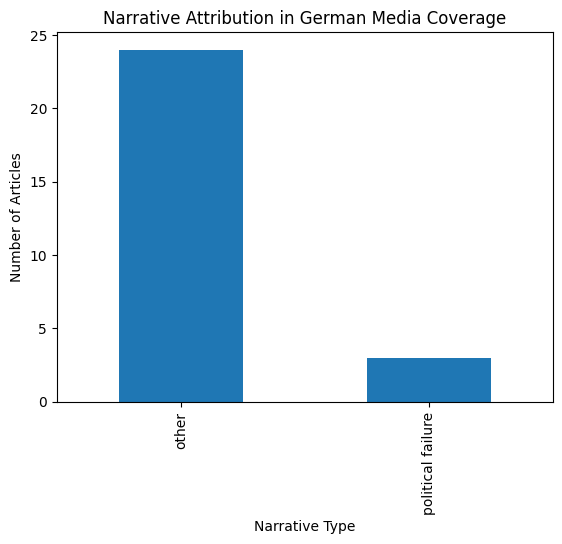

In [18]:
# Plot narrative frequencies
narrative_counts.plot(kind="bar")

plt.title("Narrative Attribution in German Media Coverage")
plt.xlabel("Narrative Type")
plt.ylabel("Number of Articles")
plt.show()

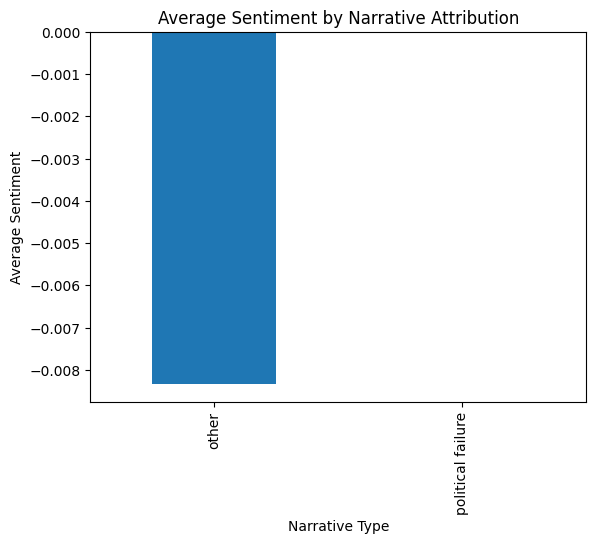

In [19]:
# Plot average sentiment by narrative
narrative_summary["sentiment"].plot(kind="bar")

plt.title("Average Sentiment by Narrative Attribution")
plt.xlabel("Narrative Type")
plt.ylabel("Average Sentiment")
plt.show()

In [22]:
import json
import pandas as pd

with open("youtube_food_inflation_germany_videos.json", "r", encoding="utf-8") as f:
    videos = json.load(f)

df_videos = pd.DataFrame(videos)

print(len(df_videos))
df_videos.head()

50


,video_id,title,description,channel,published_at
0,W3Y63qaR3Nw,Lebensmittelpreise in fünf Jahren um 37 Prozen...,Seit 2021 steigen die Lebensmittelpreise stark...,rbb24,2026-01-17T20:32:34Z
1,JJyaHj4R-g4,Das steckt wirklich hinter steigenden Lebensmi...,Lebensmittelpreise explodieren – das spüren ni...,ARD Marktcheck,2025-12-21T16:00:33Z
2,_9p087Vc8dU,Alles wird teurer – Wo die Rheinland-Pfälzer b...,"Kaffee verteuerte sich im August um 22,8 Proze...",SWR,2025-09-27T16:01:02Z
3,iQI1JaYuV2o,LEBENSMITTELPREISE im Fokus - Warum die EZB pl...,"Butter, Kaffee, Kakao – eigentlich Themen für ...",Hessischer Rundfunk,2025-11-08T16:59:50Z
4,mZYsUOrHpo0,Inflation Deutschland 2026: Dein Kaufkraftverl...,Ist die offizielle Inflation in Deutschland ei...,Lukas Finanzen,2026-02-03T08:00:50Z


In [23]:
df_videos_de = df_videos[
    df_videos["title"].str.contains("Deutschland|inflation|lebensmittel|preise|teuerung", case=False, na=False)
]

print(len(df_videos_de))
df_videos_de.head()

47


,video_id,title,description,channel,published_at
0,W3Y63qaR3Nw,Lebensmittelpreise in fünf Jahren um 37 Prozen...,Seit 2021 steigen die Lebensmittelpreise stark...,rbb24,2026-01-17T20:32:34Z
1,JJyaHj4R-g4,Das steckt wirklich hinter steigenden Lebensmi...,Lebensmittelpreise explodieren – das spüren ni...,ARD Marktcheck,2025-12-21T16:00:33Z
2,_9p087Vc8dU,Alles wird teurer – Wo die Rheinland-Pfälzer b...,"Kaffee verteuerte sich im August um 22,8 Proze...",SWR,2025-09-27T16:01:02Z
3,iQI1JaYuV2o,LEBENSMITTELPREISE im Fokus - Warum die EZB pl...,"Butter, Kaffee, Kakao – eigentlich Themen für ...",Hessischer Rundfunk,2025-11-08T16:59:50Z
4,mZYsUOrHpo0,Inflation Deutschland 2026: Dein Kaufkraftverl...,Ist die offizielle Inflation in Deutschland ei...,Lukas Finanzen,2026-02-03T08:00:50Z


In [24]:
from textblob import TextBlob

df_videos_de["sentiment"] = df_videos_de["title"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

df_videos_de["emotional_intensity"] = df_videos_de["sentiment"].abs()

df_videos_de.head()

,video_id,title,description,channel,published_at,sentiment,emotional_intensity
0,W3Y63qaR3Nw,Lebensmittelpreise in fünf Jahren um 37 Prozen...,Seit 2021 steigen die Lebensmittelpreise stark...,rbb24,2026-01-17T20:32:34Z,0.0,0.0
1,JJyaHj4R-g4,Das steckt wirklich hinter steigenden Lebensmi...,Lebensmittelpreise explodieren – das spüren ni...,ARD Marktcheck,2025-12-21T16:00:33Z,0.0,0.0
2,_9p087Vc8dU,Alles wird teurer – Wo die Rheinland-Pfälzer b...,"Kaffee verteuerte sich im August um 22,8 Proze...",SWR,2025-09-27T16:01:02Z,0.0,0.0
3,iQI1JaYuV2o,LEBENSMITTELPREISE im Fokus - Warum die EZB pl...,"Butter, Kaffee, Kakao – eigentlich Themen für ...",Hessischer Rundfunk,2025-11-08T16:59:50Z,0.0,0.0
4,mZYsUOrHpo0,Inflation Deutschland 2026: Dein Kaufkraftverl...,Ist die offizielle Inflation in Deutschland ei...,Lukas Finanzen,2026-02-03T08:00:50Z,0.0,0.0


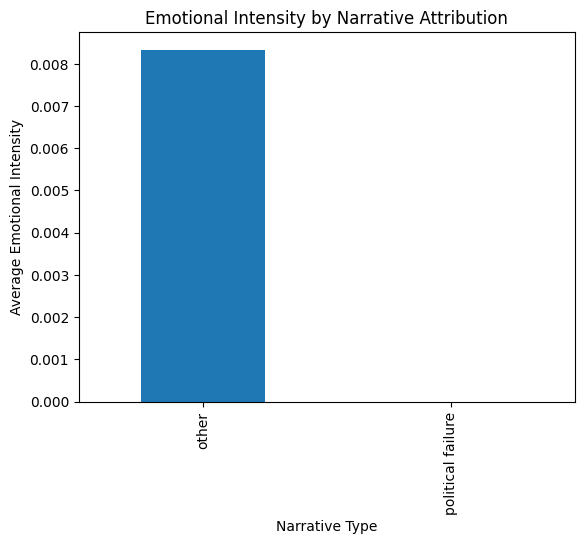

In [20]:
# Plot emotional intensity by narrative
narrative_summary["emotional_intensity"].plot(kind="bar")

plt.title("Emotional Intensity by Narrative Attribution")
plt.xlabel("Narrative Type")
plt.ylabel("Average Emotional Intensity")
plt.show()

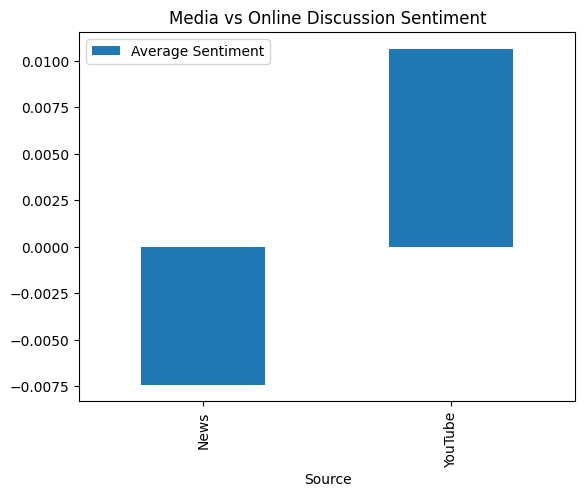

In [25]:
news_sentiment = df_food["sentiment"].mean()
youtube_sentiment = df_videos_de["sentiment"].mean()

comparison = pd.DataFrame({
    "Source": ["News", "YouTube"],
    "Average Sentiment": [news_sentiment, youtube_sentiment]
})

comparison.plot(x="Source", y="Average Sentiment", kind="bar")

import matplotlib.pyplot as plt
plt.title("Media vs Online Discussion Sentiment")
plt.show()

In [21]:
# Show selected relevant columns for interpretation
df_food[["publishedAt", "title", "narrative", "sentiment", "emotional_intensity", "url"]].head(20)

,publishedAt,title,narrative,sentiment,emotional_intensity,url
1,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...,other,0.0,0.0,https://www.zeit.de/news/2026-02/27/energie-gu...
2,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...,other,0.0,0.0,https://www.stern.de/news/verbraucherpreise--e...
3,2026-02-27 13:08:04+00:00,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,other,0.0,0.0,https://www.stern.de/gesellschaft/regional/hes...
4,2026-02-27 13:08:04+00:00,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,other,0.0,0.0,https://www.zeit.de/news/2026-02/27/mehr-kaufk...
5,2026-02-27 13:05:01+00:00,Verbraucherpreise: Energie günstiger: Inflatio...,other,0.0,0.0,https://www.tagesspiegel.de/wirtschaft/verbrau...
6,2026-02-27 13:01:50+00:00,Verbraucherpreise: Inflation sinkt im Februar ...,other,0.0,0.0,https://www.faz.net/aktuell/finanzen/finanzmar...
7,2026-02-27 10:00:38+00:00,Wirtschaftslage: Reallöhne sind 2025 erneut ge...,other,0.0,0.0,https://www.sueddeutsche.de/wirtschaft/realloh...
8,2026-02-27 08:58:19+00:00,Reallöhne: Deutsche Reallöhne sind 2025 erneut...,other,0.0,0.0,https://www.zeit.de/arbeit/2026-02/konjunktur-...
9,2026-02-27 08:11:43+00:00,Reallöhne: Deutsche Reallöhne sind 2025 erneut...,other,0.0,0.0,https://www.zeit.de/arbeit/2026-02/konjunktur-...
10,2026-02-27 07:48:11+00:00,Statistisches Bundesamt: Reallöhne im Jahr 202...,other,0.0,0.0,https://www.stern.de/wirtschaft/news/statistis...
